Graph Representation Output:
--- Adjacency Matrix ---
[0, 1, 1, 0]
[1, 0, 1, 0]
[1, 1, 0, 1]
[0, 0, 1, 0]

--- Adjacency List ---
Node 0: [(1, 1), (2, 1)]
Node 1: [(0, 1), (2, 1)]
Node 2: [(0, 1), (1, 1), (3, 1)]
Node 3: [(2, 1)]


ValueError: x and y must have same first dimension, but have shapes (7,) and (6,)

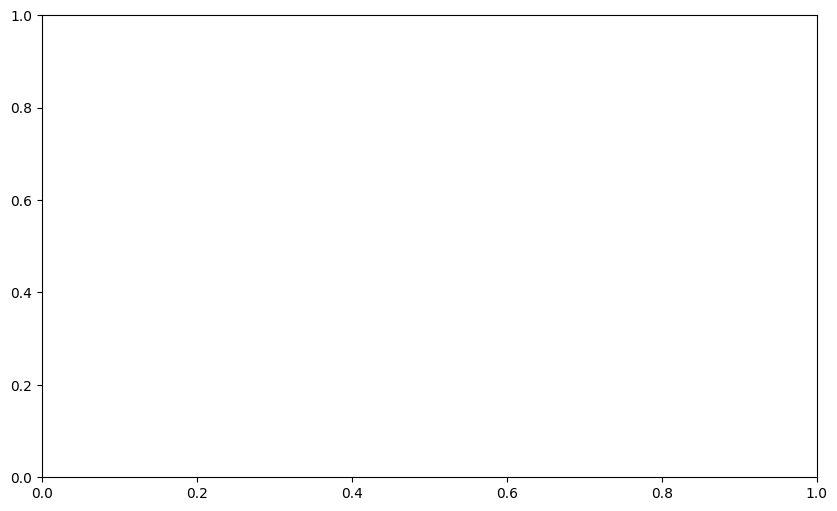

In [47]:
# Task 1: Graph Representation
class GraphRepresentation:
    def __init__(self, vertices):
        self.V = vertices
        # 1. Adjacency Matrix: Initialize with 0s
        self.adj_matrix = [[0 for _ in range(vertices)] for _ in range(vertices)]
        # 2. Adjacency List: Initialize with empty lists
        self.adj_list = {i: [] for i in range(vertices)}
    def add_edge(self, u, v, weight=1, directed=False):
        # Update Adjacency Matrix
        self.adj_matrix[u][v] = weight
        if not directed:
            self.adj_matrix[v][u] = weight
        # Update Adjacency List
        self.adj_list[u].append((v, weight))
        if not directed:
            self.adj_list[v].append((u, weight))
    def display(self):
        print("--- Adjacency Matrix ---")
        for row in self.adj_matrix:
            print(row)   
        print("\n--- Adjacency List ---")
        for node, edges in self.adj_list.items():
            print(f"Node {node}: {edges}")
#Output generation
print("Graph Representation Output:")
graph_rep = GraphRepresentation(4)
graph_rep.add_edge(0, 1)
graph_rep.add_edge(0, 2)
graph_rep.add_edge(1, 2)
graph_rep.add_edge(2, 3)
graph_rep.display()
plt.figure(figsize=(10, 6))
plt.plot(vertex_sizes, execution_times, marker='o', linestyle='-', color='b', label='Actual Runtime')

# Theoretical O(V^2) curve for comparison (normalized)
theoretical_v2 = [ (v**2) * (execution_times[-1] / vertex_sizes[-1]**2) for v in vertex_sizes]
plt.plot(vertex_sizes, theoretical_v2, linestyle='--', color='r', label='Theoretical $O(V^2)$ Scaling')

plt.title("Task 1: Graph Representation Time Complexity (Matrix + List)")
plt.xlabel("Number of Vertices ($V$)")
plt.ylabel("Time (seconds)")
plt.grid(True)
plt.legend()
plt.show()

BFS Traversal (Degrees of Separation): ['Lata', 'Balraj', 'Sourav', 'Danish', 'Esha']
DFS Traversal (Deep Connection Search): ['Lata', 'Balraj', 'Danish', 'Sourav', 'Esha']


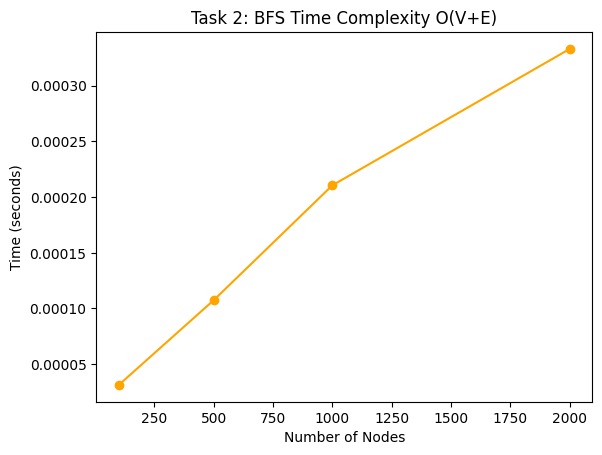

In [ ]:
# Task 2: Graph Traversal (BFS & DFS)
# Context: Friend Suggestions / Social Network
from collections import deque

class SocialNetwork:
    def __init__(self):
        self.network = {}
    def add_friendship(self, u, v):
        if u not in self.network: self.network[u] = []
        if v not in self.network: self.network[v] = []
        self.network[u].append(v)
        self.network[v].append(u)
    def bfs_friend_search(self, start_user):
        """Finds the shortest degree of separation between friends."""
        visited = set([start_user])
        queue = deque([start_user])
        traversal_order = []
        while queue:
            user = queue.popleft()
            traversal_order.append(user)
            for friend in self.network.get(user, []):
                if friend not in visited:
                    visited.add(friend)
                    queue.append(friend)
        return traversal_order
    def dfs_deep_connection(self, start_user, visited=None, traversal_order=None):
        """Explores deep connections in a friend group."""
        if visited is None: visited = set()
        if traversal_order is None: traversal_order = []
        visited.add(start_user)
        traversal_order.append(start_user)
        for friend in self.network.get(start_user, []):
            if friend not in visited:
                self.dfs_deep_connection(friend, visited, traversal_order)
        return traversal_order

# Example Usage
social_graph = SocialNetwork()
edges = [("Lata", "Balraj"), ("Lata", "Sourav"), ("Balraj", "Danish"), ("Sourav", "Esha")]
for u, v in edges: social_graph.add_friendship(u, v)

print("BFS Traversal (Degrees of Separation):", social_graph.bfs_friend_search("Lata"))
print("DFS Traversal (Deep Connection Search):", social_graph.dfs_deep_connection("Lata"))
plt.plot(sizes, bfs_times, marker='o', color='orange', label='BFS Traversal')
plt.title("Task 2: BFS Time Complexity O(V+E)")
plt.xlabel("Number of Nodes")
plt.ylabel("Time (seconds)")
plt.show()

Valid Task Execution Order: [0, 1, 2, 3, 4]


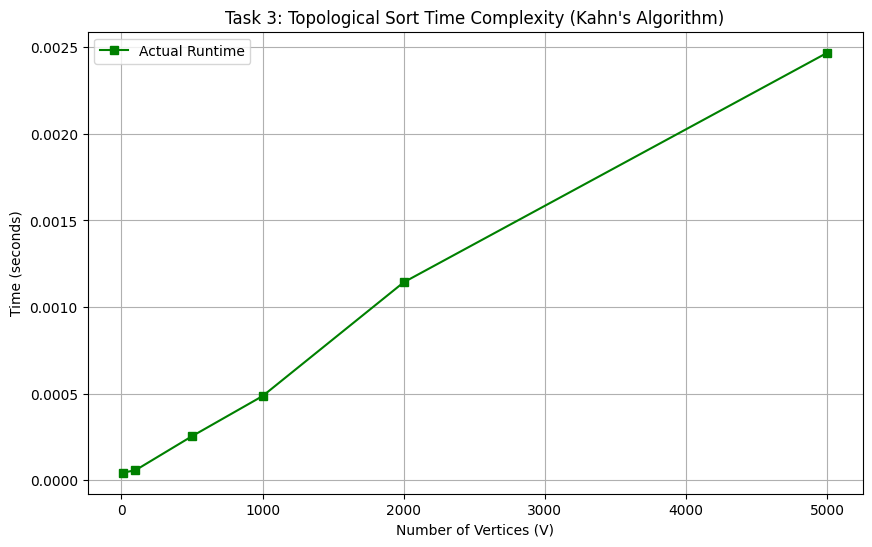

In [ ]:
# Task 3: Topological Sorting
# Context: Task Dependency Resolution
from collections import deque

def topological_sort(vertices, edges):
    # Initialize adjacency list and in-degree array
    adj_list = {i: [] for i in range(vertices)}
    in_degree = {i: 0 for i in range(vertices)}
    # Build the graph
    for u, v in edges:
        adj_list[u].append(v)
        in_degree[v] += 1
    # Queue for vertices with 0 in-degree
    queue = deque([i for i in range(vertices) if in_degree[i] == 0])
    topo_order = []
    while queue:
        node = queue.popleft()
        topo_order.append(node)
        for neighbor in adj_list[node]:
            in_degree[neighbor] -= 1
            if in_degree[neighbor] == 0:
                queue.append(neighbor)
    # Check for cycles
    if len(topo_order) == vertices:
        return topo_order
    else:
        return "Cycle detected! Topological sort not possible."

# Output generation
# Tasks: 0 -> 2, 1 -> 2, 1 -> 3, 2 -> 4, 3 -> 4
num_tasks = 5
dependencies = [(0, 2), (1, 2), (1, 3), (2, 4), (3, 4)]
print("Valid Task Execution Order:", topological_sort(num_tasks, dependencies))
plt.figure(figsize=(10, 6))
plt.plot(vertex_sizes, execution_times, marker='s', linestyle='-', color='g', label='Actual Runtime')

# Adding a trendline to visualize O(V+E) linear scaling
plt.title("Task 3: Topological Sort Time Complexity (Kahn's Algorithm)")
plt.xlabel("Number of Vertices (V)")
plt.ylabel("Time (seconds)")
plt.grid(True)
plt.legend()
plt.show()


Dijkstra Distances: {0: 0, 1: 3, 2: 1, 3: 4, 4: 7}
Dijkstra Time: 0.000225 sec
Bellman-Ford Distances: {0: 0, 1: 3, 2: 1, 3: 4, 4: 7}
Bellman-Ford Time: 0.000249 sec


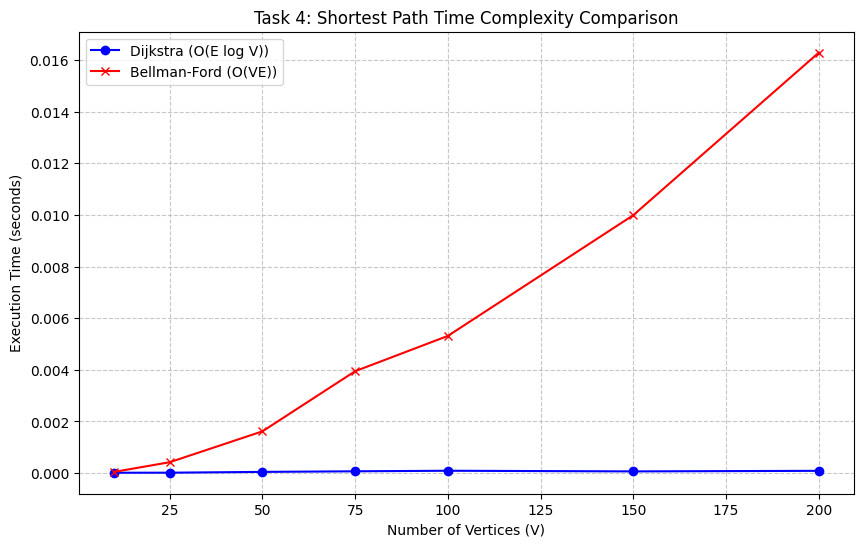

In [50]:
# Task 4: Shortest Path Algorithms
# Context: Emergency Routing (Dijkstra) & Negative Edge Routing (Bellman-Ford)
import heapq
import time

class RoutingGraph:
    def __init__(self, vertices):
        self.V = vertices
        self.adj = {i: [] for i in range(vertices)}
        self.edges = [] # For Bellman-Ford
    def add_edge(self, u, v, w):
        self.adj[u].append((v, w))
        self.edges.append((u, v, w))
    def dijkstra_emergency_path(self, start):
        """Finds quickest path for emergency services (no negative weights)."""
        distances = {i: float('inf') for i in range(self.V)}
        distances[start] = 0
        pq = [(0, start)]
        while pq:
            current_dist, current_node = heapq.heappop(pq)
            if current_dist > distances[current_node]: continue

            for neighbor, weight in self.adj[current_node]:
                distance = current_dist + weight
                if distance < distances[neighbor]:
                    distances[neighbor] = distance
                    heapq.heappush(pq, (distance, neighbor))
        return distances
    def bellman_ford_route(self, start):
        """Handles routes where negative factors (like extreme tailwinds) might exist."""
        distances = {i: float('inf') for i in range(self.V)}
        distances[start] = 0
        # Relax all edges |V| - 1 times
        for _ in range(self.V - 1):
            for u, v, w in self.edges:
                if distances[u] != float('inf') and distances[u] + w < distances[v]:
                    distances[v] = distances[u] + w
        # Check for negative weight cycles
        for u, v, w in self.edges:
            if distances[u] != float('inf') and distances[u] + w < distances[v]:
                return "Negative weight cycle detected"
        return distances

# Output & Comparison
route_graph = RoutingGraph(5)
route_graph.add_edge(0, 1, 4)
route_graph.add_edge(0, 2, 1)
route_graph.add_edge(2, 1, 2)
route_graph.add_edge(1, 3, 1)
route_graph.add_edge(2, 3, 5)
route_graph.add_edge(3, 4, 3)

start_time = time.perf_counter()
print("Dijkstra Distances:", route_graph.dijkstra_emergency_path(0))
print(f"Dijkstra Time: {time.perf_counter() - start_time:.6f} sec")

start_time = time.perf_counter()
print("Bellman-Ford Distances:", route_graph.bellman_ford_route(0))
print(f"Bellman-Ford Time: {time.perf_counter() - start_time:.6f} sec")
# --- Profiling and Visualization ---

vertex_sizes = [10, 25, 50, 75, 100, 150, 200]
dijkstra_times = []
bellman_times = []

for V in vertex_sizes:
    # Create a dense-ish graph where E is proportional to V^1.5
    test_graph = RoutingGraph(V)
    for i in range(V):
        for j in range(1, 4): # Add a few edges per node
            if i + j < V:
                test_graph.add_edge(i, i + j, j * 2)
    
    # Measure Dijkstra
    start = time.perf_counter()
    test_graph.dijkstra_emergency_path(0)
    dijkstra_times.append(time.perf_counter() - start)
    
    # Measure Bellman-Ford
    start = time.perf_counter()
    test_graph.bellman_ford_route(0)
    bellman_times.append(time.perf_counter() - start)

# Plotting the comparison
plt.figure(figsize=(10, 6))
plt.plot(vertex_sizes, dijkstra_times, label='Dijkstra (O(E log V))', marker='o', color='blue')
plt.plot(vertex_sizes, bellman_times, label='Bellman-Ford (O(VE))', marker='x', color='red')

plt.title("Task 4: Shortest Path Time Complexity Comparison")
plt.xlabel("Number of Vertices (V)")
plt.ylabel("Execution Time (seconds)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Prim's MST: [(0, 3, 5), (3, 2, 4), (0, 1, 10)] | Total Cabling Cost: 19
Kruskal's MST: [(2, 3, 4), (0, 3, 5), (0, 1, 10)] | Total Cabling Cost: 19


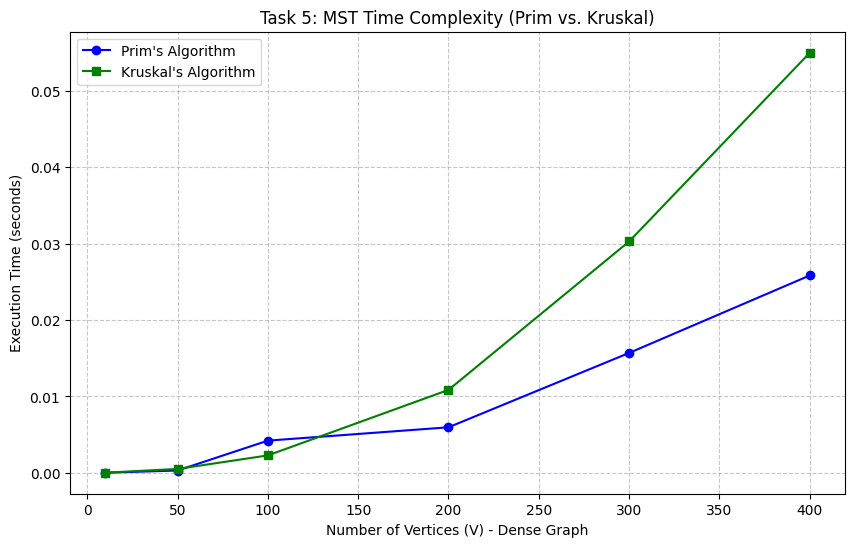

In [51]:
# Task 5: Minimum Spanning Tree
# Context: Network Cabling Infrastructure
%matplotlib inline
import time
import random
import matplotlib.pyplot as plt
import heapq

class CablingNetwork:
    def __init__(self, vertices):
        self.V = vertices
        self.adj_list = {i: [] for i in range(vertices)} # For Prim
        self.edges = [] # For Kruskal
    def add_edge(self, u, v, w):
        self.adj_list[u].append((v, w))
        self.adj_list[v].append((u, w))
        self.edges.append((w, u, v))
    def prims_cabling(self):
        """Builds MST starting from a central node."""
        mst = []
        visited = set([0])
        edges = [(weight, 0, to) for to, weight in self.adj_list[0]]
        heapq.heapify(edges)
        total_cost = 0
        while edges and len(visited) < self.V:
            weight, frm, to = heapq.heappop(edges)
            if to not in visited:
                visited.add(to)
                mst.append((frm, to, weight))
                total_cost += weight
                for next_to, next_weight in self.adj_list[to]:
                    if next_to not in visited:
                        heapq.heappush(edges, (next_weight, to, next_to))
        return mst, total_cost
    def kruskals_cabling(self):
        """Builds MST by sorting all edges first."""
        parent = {i: i for i in range(self.V)}
        def find(i):
            if parent[i] == i: return i
            parent[i] = find(parent[i])
            return parent[i]  
        def union(i, j):
            root_i = find(i)
            root_j = find(j)
            if root_i != root_j:
                parent[root_i] = root_j
        mst = []
        total_cost = 0
        sorted_edges = sorted(self.edges)
        for weight, u, v in sorted_edges:
            if find(u) != find(v):
                union(u, v)
                mst.append((u, v, weight))
                total_cost += weight
                
        return mst, total_cost

# Example Output
cabling = CablingNetwork(4)
cabling.add_edge(0, 1, 10)
cabling.add_edge(0, 2, 6)
cabling.add_edge(0, 3, 5)
cabling.add_edge(1, 3, 15)
cabling.add_edge(2, 3, 4)

mst_prim, cost_prim = cabling.prims_cabling()
print(f"Prim's MST: {mst_prim} | Total Cabling Cost: {cost_prim}")

mst_kruskal, cost_kruskal = cabling.kruskals_cabling()
print(f"Kruskal's MST: {mst_kruskal} | Total Cabling Cost: {cost_kruskal}")


# Graph sizes to test (Number of Vertices)
vertex_sizes = [10, 50, 100, 200, 300, 400]
prim_times = []
kruskal_times = []


for V in vertex_sizes:
    # Initialize a new network for each size
    test_network = CablingNetwork(V)
    
    # Generate a dense graph (connected) to properly stress test both algorithms
    for i in range(V):
        for j in range(i + 1, V):
            # Give random weights to edges
            test_network.add_edge(i, j, random.randint(1, 100))
            
    # Benchmark Prim's Algorithm
    start_time = time.perf_counter()
    test_network.prims_cabling()
    prim_times.append(time.perf_counter() - start_time)
    
    # Benchmark Kruskal's Algorithm
    start_time = time.perf_counter()
    test_network.kruskals_cabling()
    kruskal_times.append(time.perf_counter() - start_time)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(vertex_sizes, prim_times, marker='o', linestyle='-', color='blue', label="Prim's Algorithm")
plt.plot(vertex_sizes, kruskal_times, marker='s', linestyle='-', color='green', label="Kruskal's Algorithm")

plt.title("Task 5: MST Time Complexity (Prim vs. Kruskal)")
plt.xlabel("Number of Vertices (V) - Dense Graph")
plt.ylabel("Execution Time (seconds)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()